<a href="https://colab.research.google.com/github/Typicalanne/Typicalanne/blob/main/Ice_Task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
drive.mount('/content/drive/')

Mounted at /content/drive/


**Import Both Datasets**

In [ ]:
file1 = '/content/drive/My Drive/Colab Notebooks/train_energy_data.csv'
file2 = '/content/drive/My Drive/Colab Notebooks/test_energy_data.csv'

In [ ]:
df1 = pd.read_csv(file1)
df2 = pd.read_csv(file2)

In [ ]:
df1.head(5)

,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption
0,Residential,7063,76,10,29.84,Weekday,2713.95
1,Commercial,44372,66,45,16.72,Weekday,5744.99
2,Industrial,19255,37,17,14.30,Weekend,4101.24
3,Residential,13265,14,41,32.82,Weekday,3009.14
4,Commercial,13375,26,18,11.92,Weekday,3279.17


In [ ]:
df2.head(5)

,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption
0,Residential,24563,15,4,28.52,Weekday,2865.57
1,Commercial,27583,56,23,23.07,Weekend,4283.80
2,Commercial,45313,4,44,33.56,Weekday,5067.83
3,Residential,41625,84,17,27.39,Weekend,4624.30
4,Residential,36720,58,47,17.08,Weekday,4820.59


In [ ]:
df1.shape

(1000, 7)

In [ ]:
df2.shape

(100, 7)

**Deal with Null Values**

In [ ]:
df1.isnull().sum()

,0
Building Type,0
Square Footage,0
Number of Occupants,0
Appliances Used,0
Average Temperature,0
Day of Week,0
Energy Consumption,0


In [ ]:
df2.isnull().sum()

,0
Building Type,0
Square Footage,0
Number of Occupants,0
Appliances Used,0
Average Temperature,0
Day of Week,0
Energy Consumption,0


**Count the number of unique values for categorical variables**

In [ ]:
df1['Building Type'].value_counts()

,count
Building Type,
Residential,347
Commercial,336
Industrial,317


In [ ]:
df1['Building Type'].unique()

array(['Residential', 'Commercial', 'Industrial'], dtype=object)

In [ ]:
df1['Day of Week'].value_counts()

,count
Day of Week,
Weekday,507
Weekend,493


**CHECK CORRELATION**

In [ ]:
#Make copies of the data first
df = df1.copy()

In [ ]:
df.drop(columns=['Building Type', 'Day of Week'], inplace=True)

In [ ]:
df.head(5)

,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption
0,Residential,7063,76,10,29.84,Weekday,2713.95
1,Commercial,44372,66,45,16.72,Weekday,5744.99
2,Industrial,19255,37,17,14.30,Weekend,4101.24
3,Residential,13265,14,41,32.82,Weekday,3009.14
4,Commercial,13375,26,18,11.92,Weekday,3279.17


In [ ]:
df.corr()

,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Energy Consumption
Square Footage,1.000000,0.033379,-0.013478,0.027273,0.774873
Number of Occupants,0.033379,1.000000,0.023646,0.014122,0.354485
Appliances Used,-0.013478,0.023646,1.000000,-0.062870,0.312792
Average Temperature,0.027273,0.014122,-0.062870,1.000000,-0.034487
Energy Consumption,0.774873,0.354485,0.312792,-0.034487,1.000000


In [ ]:
import seaborn as sns

<Axes: >

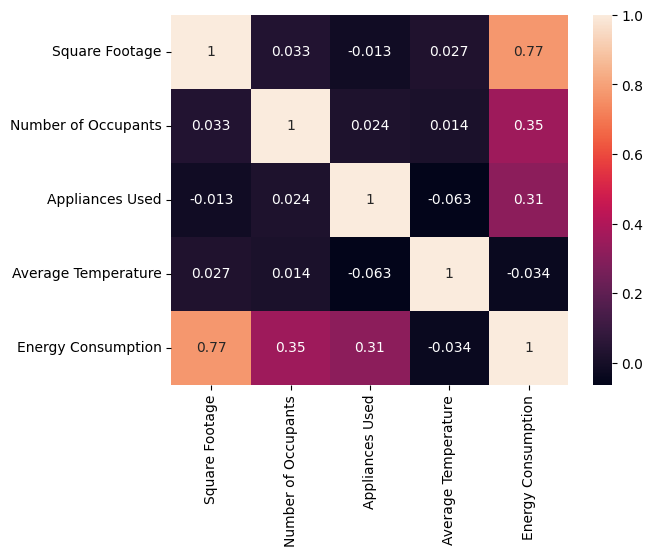

In [ ]:
#Check correlation using heatmap
sns.heatmap(df.corr(), annot=True)

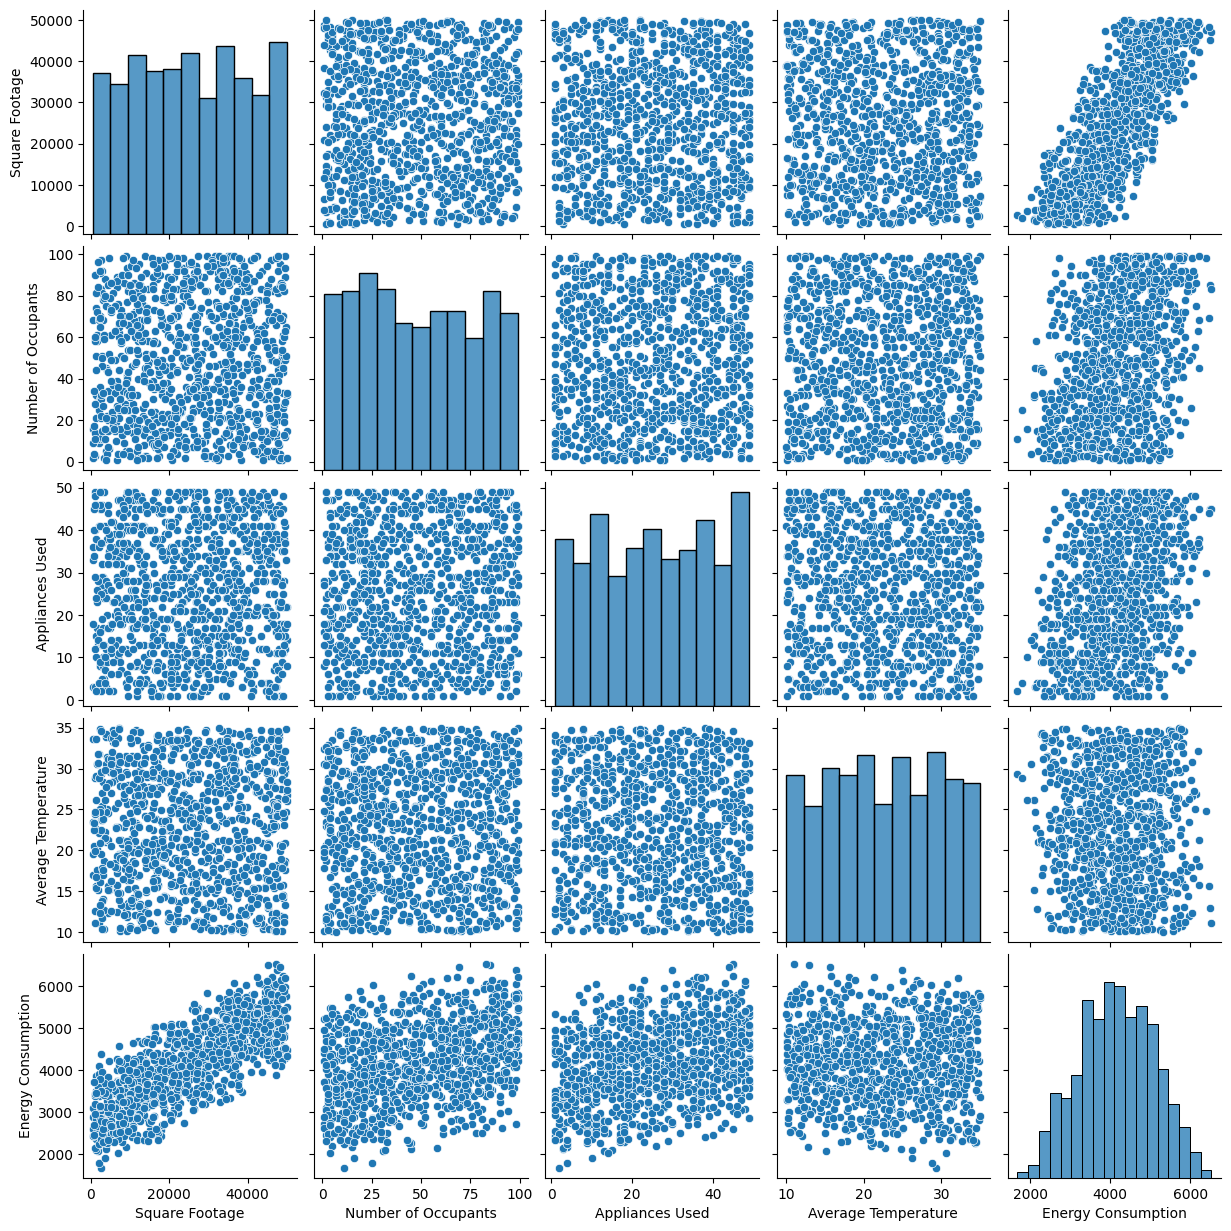

In [ ]:
import matplotlib.pyplot as plt
sns.pairplot(df)

**VISUALIZE THE DISTRIBUTION**

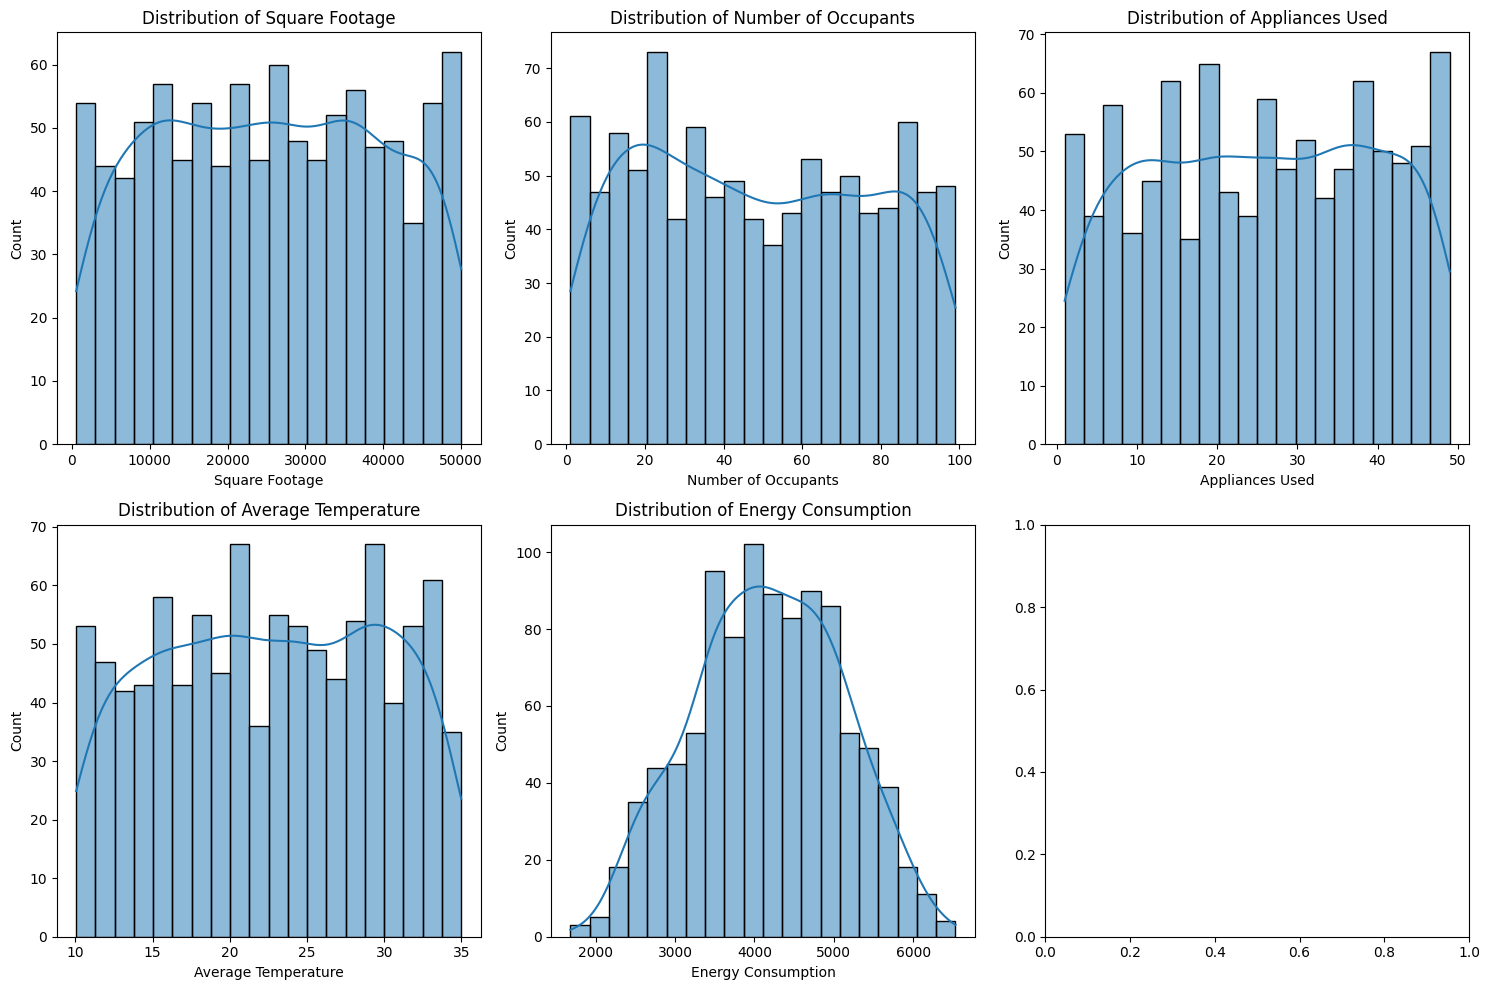

In [ ]:
fig, axes = plt.subplots(len(df.columns) //2, 3, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(df.columns):
  sns.histplot(df[col], bins=20, kde=True, ax=axes[i])
  axes[i].set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

In [ ]:
for col in df.columns:
  print(f"{col} has a skew value of: {df[col].skew()}")

Square Footage has a skew value of: 0.009312560853110174
Number of Occupants has a skew value of: 0.08930191275350645
Appliances Used has a skew value of: -0.03739186781505198
Average Temperature has a skew value of: -0.04040584079425753
Energy Consumption has a skew value of: -0.04624062440775178


**ENCODE CATEGORICAL DATA**

In [ ]:
from sklearn.preprocessing import OneHotEncoder

In [ ]:
encoder = OneHotEncoder(sparse_output = False)

In [ ]:
#Encode building type for both training and testing set
building_type = encoder.fit_transform(df1[['Building Type']])
building_type_df1 = pd.DataFrame(building_type, columns=encoder.get_feature_names_out())
building_type2 = encoder.transform(df2[['Building Type']])
building_type_df2 = pd.DataFrame(building_type2, columns=encoder.get_feature_names_out())

In [ ]:
#Encode week of day for both training and testing set
week_of_day = encoder.fit_transform(df1[['Day of Week']])
week_of_day_df1 = pd.DataFrame(week_of_day, columns=encoder.get_feature_names_out())
week_of_day2 = encoder.transform(df2[['Day of Week']])
week_of_day_df2 = pd.DataFrame(week_of_day2, columns=encoder.get_feature_names_out())

In [ ]:
#Simulate Loading the Dataset
np.random.seed(42)
df = pd.DataFrame({
    "Temperature": np.random.normal(20, 5, 100),
    "Humidity": np.random.normal(50, 10, 100),
    "Visibility": np.random.normal(10, 2, 100),
    "Wind Speed": np.random.normal(5, 1, 100),
    "General Diffuse Flows": np.random.normal(200, 50, 100),
    "Diffuse Flows": np.random.normal(100, 20, 100),
    "Energy Consumption": np.random.normal(300, 75, 100)
})

In [ ]:
# Introduce some missing values in 'Humidity'
df.loc[::10, "Humidity"] = np.nan

In [ ]:
# Fill missing values with the median of each numeric column
df.fillna(df.median(numeric_only=True), inplace=True)

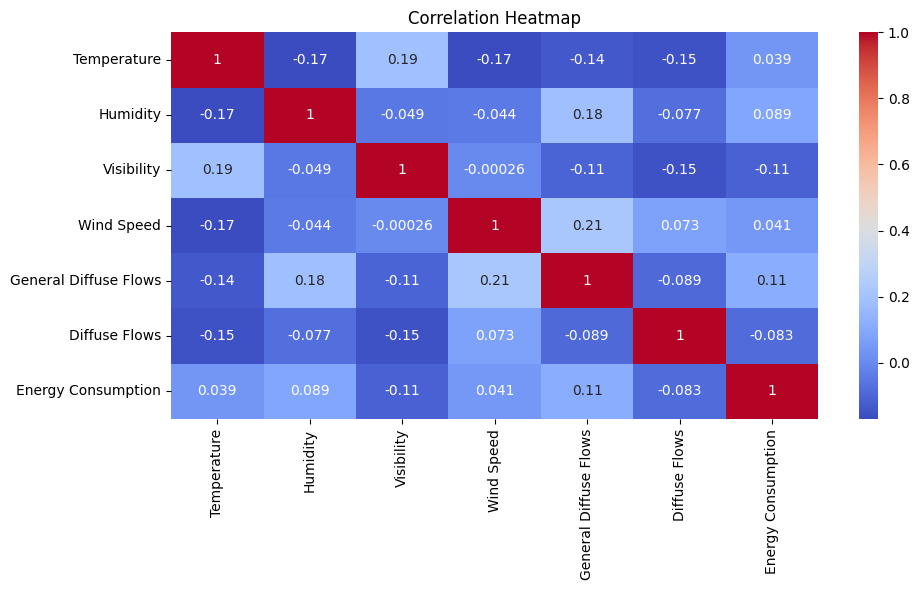

In [ ]:
# Heatmap to check correlation
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

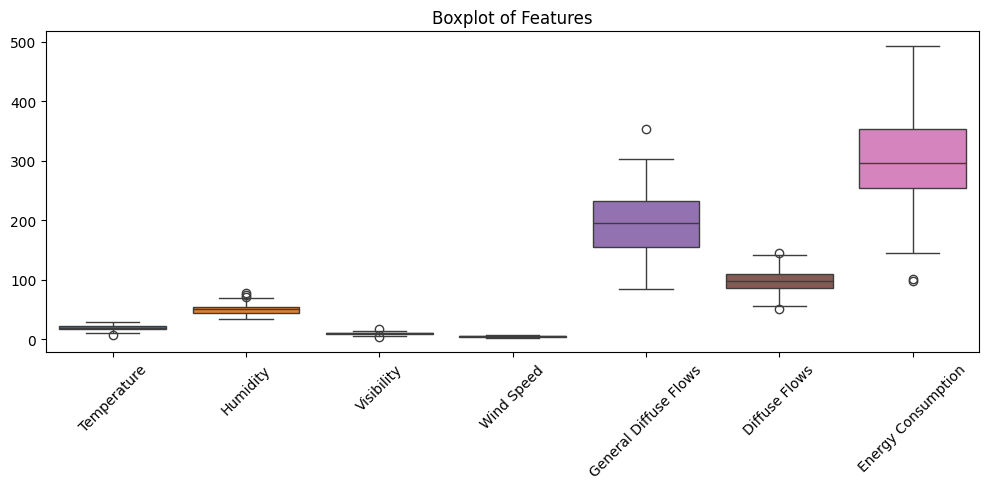

In [ ]:
# Boxplot to detect outliers
plt.figure(figsize=(10, 5))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.title("Boxplot of Features")
plt.tight_layout()
plt.show()

In [ ]:
# Features (X) and Target (y)
X = df.drop("Energy Consumption", axis=1)
y = df["Energy Consumption"]

In [ ]:
# Split data into training and testing sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Build Multiple Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
# Use Model for Prediction
y_pred = model.predict(X_test)

In [ ]:
 Evaluate the Model
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

In [ ]:
# Output Results
print("Intercept:", model.intercept_)
print("Coefficients:", dict(zip(X.columns, model.coef_)))
print("RMSE:", rmse)
print("R² Score:", r2)

Intercept: 318.05799704513123
Coefficients: {'Temperature': np.float64(0.753250199791232), 'Humidity': np.float64(-0.07420097652388635), 'Visibility': np.float64(-5.5541585027547775), 'Wind Speed': np.float64(7.523956941361524), 'General Diffuse Flows': np.float64(0.19464128955837398), 'Diffuse Flows': np.float64(-0.5197986175359378)}
RMSE: 81.1437858901265
R² Score: -0.18361979631652092


In [ ]:
# Load test data
test_df = pd.read_csv('/content/drive/My Drive/Colab Notebooks/test_energy_data.csv')

In [ ]:
# Encode categorical variables just like training set
test_df_encoded = pd.get_dummies(test_df, columns=['Building Type', 'Day of Week'], drop_first=True)

In [ ]:
# Make sure test set has same columns as training set
for col in X.columns:
    if col not in test_df_encoded:
        test_df_encoded[col] = 0
test_df_encoded = test_df_encoded[X.columns]  # reorder columns

In [ ]:
# Predict
test_predictions = model.predict(test_df_encoded)
print("\n📊 Test Set Predictions:\n", test_predictions)


📊 Test Set Predictions:
 [318.05799705 318.05799705 318.05799705 318.05799705 318.05799705
 318.05799705 318.05799705 318.05799705 318.05799705 318.05799705
 318.05799705 318.05799705 318.05799705 318.05799705 318.05799705
 318.05799705 318.05799705 318.05799705 318.05799705 318.05799705
 318.05799705 318.05799705 318.05799705 318.05799705 318.05799705
 318.05799705 318.05799705 318.05799705 318.05799705 318.05799705
 318.05799705 318.05799705 318.05799705 318.05799705 318.05799705
 318.05799705 318.05799705 318.05799705 318.05799705 318.05799705
 318.05799705 318.05799705 318.05799705 318.05799705 318.05799705
 318.05799705 318.05799705 318.05799705 318.05799705 318.05799705
 318.05799705 318.05799705 318.05799705 318.05799705 318.05799705
 318.05799705 318.05799705 318.05799705 318.05799705 318.05799705
 318.05799705 318.05799705 318.05799705 318.05799705 318.05799705
 318.05799705 318.05799705 318.05799705 318.05799705 318.05799705
 318.05799705 318.05799705 318.05799705 318.057997